# H05：固定初筛名单的机会命中诊断

本 Notebook 执行 [README 的 H05](README.md#h05-固定名单的机会命中诊断)。固定 H04 已保存的预测和每日50只名单，检验收益分布前部机会的命中、召回和富集。

**本轮是已查看历史上的探索性补充，不是新的独立验证。机会是 `y_rank_return > 0.9`，仍为既有持有窗口的相对收益代理，不代表正收益、实际成交或 L2 的观察价值。**

已执行结果：原主候选在102日开发段确认命中229/5100（Precision **4.4902%**），后续17日38/850（**4.4706%**）；成交额对照分别为22.0000%、17.1765%，随机期望约10%。原主候选每天50只平均命中约2.24只，未富集前10%机会。八组模型的开发段命中比例均低于随机期望。

1,190个模型日逐一重算一致；211种缺失情形与781种未知事件赋值通过边界检查。表中的 Precision 为已确认命中比例，缺失上界及 Recall/F1/Lift 边界均保留。L2消融的保守差为负不能单独证明真实增量为负。

证据：`/home/wsw/app/research-evidence/subscription-opportunity-metrics-2026-09-22-zg1az9fa/`。原排名模型没有按此次二分类事件重训，不能据此判断直接预测事件概率的模型效果。

**数据质量限制：** 结果后确认6月8/9日的五分钟入退场窗口在去掉日期偏移后全部分钟字段相同，形成大量零收益标签。数值统计仍描述冻结数据；模型经济效果的判断须等待上游质量问题澄清。日期与分数均未改动，详见第8节。

## 1. 方法、来源与输入快照

- 开发段：2026-03-27..08-24，102日，原八候选和三个简单规则。
- 后续段：2026-08-26..09-17，17日，仅 H04 原主候选、原参照、日频消融和成交额规则。
- 主候选仍为 `ridge_all__expanding`；不按本次指标重新选择后续赢家。
- 全市场标签的原百分位不重排；召回范围限于 P 日已知、当时实际可选的股票池。
- 日等权；K=50 仅为诊断规模，真实股票数取决于 topic 组合和预算。
- 所有读入文件从已冻结的 H04 归档复制、核对其既有 SHA-256；无需正式数据或生产凭证。
- 缺失标签界描述未知结果；bootstrap 区间描述日期抽样不确定性，两者分别报告。


In [1]:
import hashlib
import importlib.metadata
import itertools
import json
import shutil
import subprocess
import tempfile
from datetime import UTC, datetime
from pathlib import Path
from typing import TypedDict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib import font_manager, ticker
from sklearn.metrics import f1_score, precision_score, recall_score


class _InputFile(TypedDict):
    path: str
    sha256: str
    bytes: int


primary = "ridge_all__expanding"
comparator = "baseline_amount"

source = Path("/home/wsw/app/dev/trading")
topic = source / "research/subscription-training"
prior = Path(
    "/home/wsw/app/research-evidence/subscription-revalidation-2026-09-21-plweybse"
)
evidence = Path(
    tempfile.mkdtemp(
        prefix="subscription-opportunity-metrics-2026-09-22-", dir=prior.parent
    )
)
inputs = evidence / "inputs"
inputs.mkdir()
parameters = {
    "rank_cutoff_strict": 0.9,
    "selected_count": 50,
    "seed": 20260922,
    "bootstrap_repetitions": 10000,
    "primary_block_days": 5,
    "sensitivity_block_days": [1, 3],
    "primary": primary,
    "comparator": comparator,
    "posthoc": True,
}
(evidence / "parameters.json").write_text(json.dumps(parameters, indent=2) + "\n")
shutil.copy2(topic / "README.md", evidence / "preregistered-README.md")
shutil.copy2(topic / "opportunity_metrics.ipynb", evidence / "source-notebook.ipynb")
shutil.copy2(source / "uv.lock", evidence / "uv.lock")
expected = {
    relative: digest
    for digest, relative in (
        line.split("  ", 1) for line in (prior / "SHA256SUMS").read_text().splitlines()
    )
}
names = [
    "panel.parquet",
    "development-metrics.parquet",
    "new-metrics.parquet",
    "selection-frozen.json",
    "run.json",
    "validate_training.py",
    "source.tar",
    "preregistered-README.md",
    "new-summary.json",
]
for directory in [
    "development-last60",
    "development-expanding",
    "new-primary",
    "new-reference",
    "new-ablation",
]:
    names.extend(
        str(path.relative_to(prior))
        for path in sorted((prior / directory).glob("predictions-*.parquet"))
    )
manifest: list[_InputFile] = []
for name in names:
    origin = prior / name
    with origin.open("rb") as handle:
        digest = hashlib.file_digest(handle, "sha256").hexdigest()
    assert digest == expected[name], name
    target = inputs / name
    target.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(origin, target)
    with target.open("rb") as handle:
        assert hashlib.file_digest(handle, "sha256").hexdigest() == digest
    manifest.append({"path": name, "sha256": digest, "bytes": origin.stat().st_size})
(evidence / "input-manifest.json").write_text(json.dumps(manifest, indent=2) + "\n")
run = {
    "base_commit": subprocess.check_output(
        ["git", "rev-parse", "HEAD"], cwd=source, text=True
    ).strip(),
    "worktree_before": subprocess.check_output(
        ["git", "status", "--short"], cwd=source, text=True
    ),
    "prior_evidence": str(prior),
    "created_at_utc": datetime.now(UTC).isoformat(),
    "parameters": parameters,
    "versions": {
        name: importlib.metadata.version(name)
        for name in ["numpy", "pandas", "pyarrow", "scikit-learn", "matplotlib"]
    },
    "retention": "until user research decision and review complete",
}
(evidence / "run.json").write_text(json.dumps(run, ensure_ascii=False, indent=2) + "\n")
panel = pd.read_parquet(
    inputs / "panel.parquet",
    columns=[
        "symbol",
        "trade_date",
        "y_rank_return",
        "baseline_amount",
        "baseline_momentum",
        "baseline_reversal",
    ],
)
assert not panel.duplicated(["trade_date", "symbol"]).any()
frames = {
    day: frame.set_index("symbol")
    for day, frame in panel.groupby("trade_date", sort=True)
}
original = pd.concat(
    [
        pd.read_parquet(inputs / "development-metrics.parquet").assign(
            stage="development"
        ),
        pd.read_parquet(inputs / "new-metrics.parquet").assign(stage="followup"),
    ],
    ignore_index=True,
)
assert not original.duplicated(["stage", "trade_date", "method"]).any()
assert original.groupby("stage")["trade_date"].nunique().to_dict() == {
    "development": 102,
    "followup": 17,
}
frozen = json.loads((inputs / "selection-frozen.json").read_text())
assert (
    frozen["candidate"] == parameters["primary"]
    and frozen["comparator"] == parameters["comparator"]
)
font_path = prior / "NotoSansCJKsc-Regular.otf"
shutil.copy2(font_path, evidence / font_path.name)
font_manager.fontManager.addfont(str(evidence / font_path.name))
plt.rcParams.update(
    {
        "font.family": font_manager.FontProperties(
            fname=evidence / font_path.name
        ).get_name(),
        "font.size": 11,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.unicode_minus": False,
        "figure.dpi": 120,
    }
)
print("Evidence:", evidence)
print(
    "Frozen inputs:",
    len(manifest),
    "files;",
    sum(item["bytes"] for item in manifest),
    "bytes",
)
print("Model-date evaluations:", len(original))

Evidence: /home/wsw/app/research-evidence/subscription-opportunity-metrics-2026-09-22-zg1az9fa
Frozen inputs: 264 files; 295211145 bytes
Model-date evaluations: 1190


## 2. 每日计数与缺失标签边界

H 为已确认命中数，A 为已选但标签未知数，B 为未选且标签未知数，M 为全池已知机会数，N 为事前池大小。

| 指标 | 下界 | 上界 |
|---|---|---|
| Precision | H/K | (H+A)/K |
| Recall | H/(M+B) | (H+A)/(M+A) |
| F1 | 2H/(K+M+B) | 2(H+A)/(K+M+A) |
| 随机 Precision 期望 | M/N | (M+A+B)/N |
| Lift | (N/K)×Recall下界 | (N/K)×Recall上界 |

另外报告 H/M，含义仅为“已知机会的召回”。不把未知结果视为真实负例，也不根据标签可用性重选名单。


In [2]:
def _add_metrics(counts: pd.DataFrame) -> pd.DataFrame:
    result = counts.copy()
    hits = result["hits"]
    selected = result["selected_count"]
    known = result["known_positive"]
    inside = result["selected_unknown"]
    outside = result["unknown_count"] - inside
    result["precision_lower"] = hits / selected
    result["precision_upper"] = (hits + inside) / selected
    result["recall_known"] = hits / known
    result["recall_lower"] = hits / (known + outside)
    result["recall_upper"] = (hits + inside) / (known + inside)
    result["f1_lower"] = 2 * hits / (selected + known + outside)
    result["f1_upper"] = 2 * (hits + inside) / (selected + known + inside)
    result["random_lower"] = known / result["pool_size"]
    result["random_upper"] = (known + result["unknown_count"]) / result["pool_size"]
    result["lift_lower"] = result["pool_size"] / selected * result["recall_lower"]
    result["lift_upper"] = result["pool_size"] / selected * result["recall_upper"]
    result["label_coverage"] = 1 - inside / selected
    return result


rows = []
for row in original.itertuples(index=False):
    labels = frames[row.trade_date]["y_rank_return"]
    selected = list(row.selected_symbols)
    assert len(selected) == len(set(selected)) == parameters["selected_count"]
    assert set(selected).issubset(labels.index)
    known_positive = int(labels.gt(parameters["rank_cutoff_strict"]).sum())
    assert known_positive > 0
    chosen = labels.loc[selected]
    assert len(labels) == row.pool_size and int(chosen.notna().sum()) == row.label_count
    rows.append(
        {
            "stage": row.stage,
            "trade_date": row.trade_date,
            "method": row.method,
            "pool_size": len(labels),
            "known_positive": known_positive,
            "unknown_count": int(labels.isna().sum()),
            "selected_count": len(selected),
            "selected_unknown": int(chosen.isna().sum()),
            "hits": int(chosen.gt(parameters["rank_cutoff_strict"]).sum()),
        }
    )
counts = pd.DataFrame(rows)
daily = _add_metrics(counts)
daily.to_parquet(evidence / "daily-metrics.parquet", index=False)
metrics = [
    "precision_lower",
    "precision_upper",
    "recall_known",
    "recall_lower",
    "recall_upper",
    "f1_lower",
    "f1_upper",
    "random_lower",
    "random_upper",
    "lift_lower",
    "lift_upper",
    "label_coverage",
]
summary = (
    daily.groupby(["stage", "method"], sort=True)
    .agg(
        days=("trade_date", "size"),
        hits=("hits", "sum"),
        mean_hits=("hits", "mean"),
        selected=("selected_count", "sum"),
        selected_unknown=("selected_unknown", "sum"),
        **{name: (name, "mean") for name in metrics},
    )
    .reset_index()
)
summary.to_csv(evidence / "summary.csv", index=False)
universe = daily.drop_duplicates(["stage", "trade_date"])[
    [
        "stage",
        "trade_date",
        "pool_size",
        "known_positive",
        "unknown_count",
        "random_lower",
        "random_upper",
    ]
]
universe.to_csv(evidence / "daily-universe.csv", index=False)
display(
    universe.groupby("stage").agg(
        days=("trade_date", "size"),
        min_pool=("pool_size", "min"),
        max_pool=("pool_size", "max"),
        min_known_opportunities=("known_positive", "min"),
        max_known_opportunities=("known_positive", "max"),
        unknown_labels=("unknown_count", "sum"),
    )
)
labels_map = {
    "baseline_amount": "成交额规则",
    "baseline_momentum": "动量规则",
    "baseline_reversal": "反转规则",
}
for candidate, caption in [
    ("ridge_daily", "Ridge 日频"),
    ("ridge_all", "Ridge 日频+L2"),
    ("hist_daily", "浅树 日频"),
    ("hist_all", "浅树 日频+L2"),
]:
    for window, window_caption in [("last60", "近60日"), ("expanding", "扩展历史")]:
        labels_map[f"{candidate}__{window}"] = f"{caption} / {window_caption}"

,days,min_pool,max_pool,min_known_opportunities,max_known_opportunities,unknown_labels
stage,,,,,,
development,102,5150,5204,90,521,1083
followup,17,5204,5208,519,521,111


## 3. 开发段：固定名单的机会密度

102日，原模型与规则全部列出；排序只是展示本次诊断，不改变 H04 冻结选择。图中点为 Precision 缺失下界，短横线为缺失标签界，不是置信区间。随机参照按各日实际池内机会比例计算，并非硬设为10%。


,每日确认命中/50,Precision下界,Precision上界,Lift下界,Lift上界,未知入选股票日
method,,,,,,
动量规则,11.77,23.55%,23.86%,2.340,2.418,16
成交额规则,11.00,22.00%,22.00%,2.159,2.204,0
反转规则,7.65,15.29%,16.90%,1.526,1.718,82
浅树 日频+L2 / 近60日,4.53,9.06%,9.16%,0.891,0.926,5
浅树 日频 / 近60日,3.50,7.00%,7.39%,0.690,0.740,20
浅树 日频+L2 / 扩展历史,3.42,6.84%,6.90%,0.692,0.710,3
Ridge 日频 / 近60日,3.41,6.82%,7.59%,0.681,0.778,39
Ridge 日频+L2 / 近60日,3.20,6.39%,6.59%,0.646,0.679,10
浅树 日频 / 扩展历史,2.72,5.43%,5.90%,0.544,0.600,24


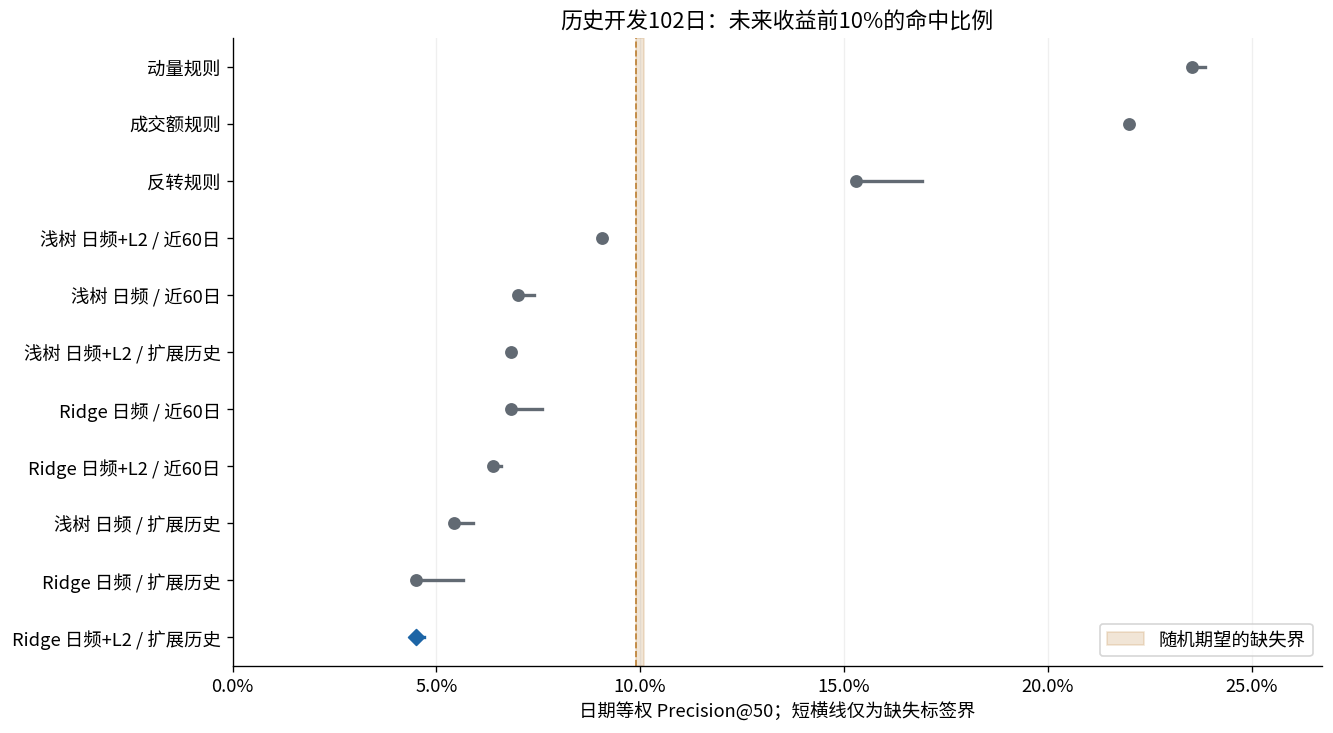

,已知机会Recall,Recall下界,Recall上界,F1下界,F1上界,标签覆盖
method,,,,,,
动量规则,2.30%,2.25%,2.33%,4.10%,4.23%,99.69%
成交额规则,2.12%,2.08%,2.12%,3.80%,3.87%,100.00%
反转规则,1.49%,1.47%,1.66%,2.67%,3.00%,98.39%
浅树 日频+L2 / 近60日,0.87%,0.86%,0.89%,1.57%,1.62%,99.90%
浅树 日频 / 近60日,0.68%,0.66%,0.71%,1.21%,1.30%,99.61%
浅树 日频+L2 / 扩展历史,0.68%,0.67%,0.68%,1.21%,1.24%,99.94%
Ridge 日频 / 近60日,0.67%,0.66%,0.75%,1.19%,1.36%,99.24%
Ridge 日频+L2 / 近60日,0.63%,0.62%,0.65%,1.13%,1.18%,99.80%
浅树 日频 / 扩展历史,0.53%,0.52%,0.58%,0.95%,1.05%,99.53%


In [3]:
development = summary.loc[summary["stage"].eq("development")].sort_values(
    "precision_lower", ascending=False
)
table = development.set_index("method")[
    [
        "mean_hits",
        "precision_lower",
        "precision_upper",
        "lift_lower",
        "lift_upper",
        "selected_unknown",
    ]
].rename(index=labels_map)
table.columns = [
    "每日确认命中/50",
    "Precision下界",
    "Precision上界",
    "Lift下界",
    "Lift上界",
    "未知入选股票日",
]
display(
    table.style.format(
        {
            "每日确认命中/50": "{:.2f}",
            "Precision下界": "{:.2%}",
            "Precision上界": "{:.2%}",
            "Lift下界": "{:.3f}",
            "Lift上界": "{:.3f}",
            "未知入选股票日": "{:.0f}",
        }
    )
)
fig, ax = plt.subplots(figsize=(11, 6), layout="constrained")
for position, row in enumerate(development.itertuples(index=False)):
    color = "#1d65a6" if row.method == primary else "#626a73"
    ax.plot(
        [row.precision_lower, row.precision_upper],
        [position, position],
        color=color,
        linewidth=2,
    )
    ax.scatter(
        row.precision_lower,
        position,
        color=color,
        marker="D" if row.method == primary else "o",
        s=45,
    )
ax.set_yticks(
    range(len(development)), [labels_map[name] for name in development["method"]]
)
ax.invert_yaxis()
random_bounds = universe.loc[
    universe["stage"].eq("development"), ["random_lower", "random_upper"]
].mean()
ax.axvspan(
    random_bounds.iloc[0],
    random_bounds.iloc[1],
    color="#bc8033",
    alpha=0.2,
    label="随机期望的缺失界",
)
ax.axvline(random_bounds.iloc[0], color="#bc8033", linestyle="--", linewidth=1)
ax.set_xlim(0, max(development["precision_upper"].max(), random_bounds.iloc[1]) * 1.12)
ax.xaxis.set_major_formatter(ticker.PercentFormatter(1))
ax.set_xlabel("日期等权 Precision@50；短横线仅为缺失标签界")
ax.set_title("历史开发102日：未来收益前10%的命中比例")
ax.grid(axis="x", alpha=0.2)
ax.legend(loc="lower right")
fig.savefig(evidence / "development-precision.png")
plt.show()
rf = development.set_index("method")[
    [
        "recall_known",
        "recall_lower",
        "recall_upper",
        "f1_lower",
        "f1_upper",
        "label_coverage",
    ]
].rename(index=labels_map)
rf.columns = [
    "已知机会Recall",
    "Recall下界",
    "Recall上界",
    "F1下界",
    "F1上界",
    "标签覆盖",
]
display(rf.style.format("{:.2%}"))

## 4. 后续17日：原冻结角色的补充诊断

这17日已经用于 H04；本轮指标是在查看旧结果后确定，必须按探索性结果解释。主候选、参照、消融保持原角色。表中的小数比例显示为百分比；Lift=1 对应池内均匀随机选择的机会密度。


,确认命中总数,每日确认命中/50,Precision下界,Precision上界,Lift下界,Lift上界,未知入选股票日
method,,,,,,,
Ridge 日频+L2 / 扩展历史,38,2.24,4.47%,4.94%,0.442,0.494,4
成交额规则,146,8.59,17.18%,17.18%,1.696,1.718,0
浅树 日频+L2 / 近60日,33,1.94,3.88%,4.00%,0.384,0.400,1
Ridge 日频 / 扩展历史,37,2.18,4.35%,5.88%,0.431,0.587,13


,已知机会Recall,Recall下界,Recall上界,F1下界,F1上界,标签覆盖
method,,,,,,
Ridge 日频+L2 / 扩展历史,0.43%,0.42%,0.47%,0.78%,0.87%,99.53%
成交额规则,1.65%,1.63%,1.65%,2.98%,3.01%,100.00%
浅树 日频+L2 / 近60日,0.37%,0.37%,0.38%,0.67%,0.70%,99.88%
Ridge 日频 / 扩展历史,0.42%,0.41%,0.56%,0.76%,1.03%,98.47%


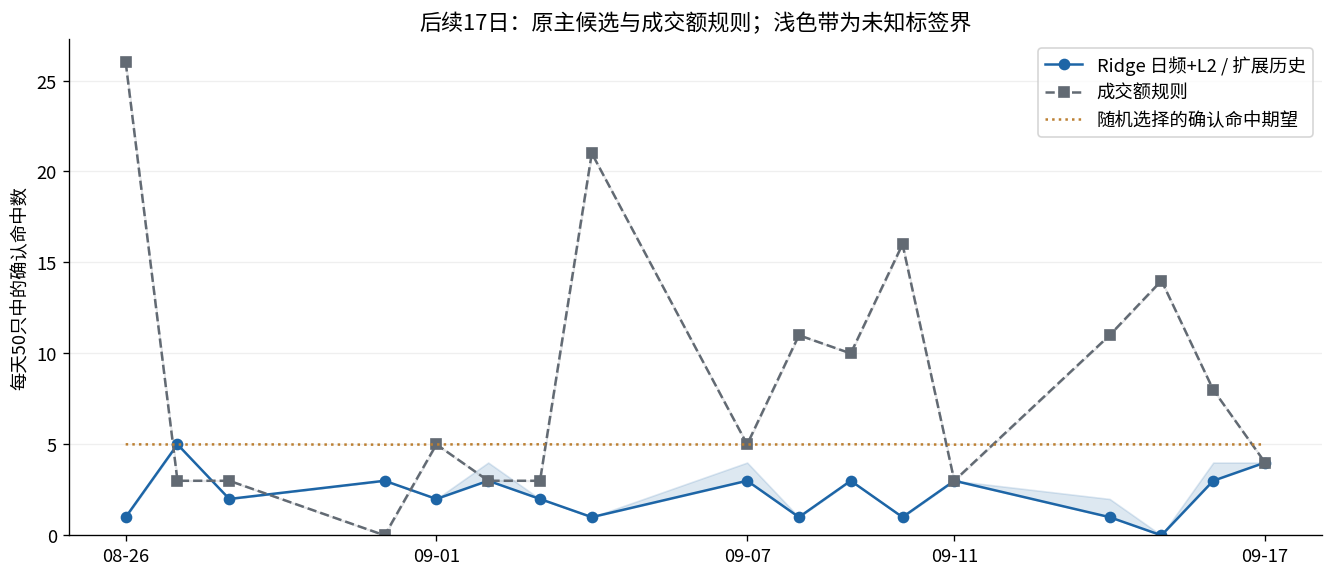

In [4]:
followup = (
    summary.loc[summary["stage"].eq("followup")]
    .set_index("method")
    .loc[[primary, comparator, "hist_all__last60", "ridge_daily__expanding"]]
)
display(
    followup[
        [
            "hits",
            "mean_hits",
            "precision_lower",
            "precision_upper",
            "lift_lower",
            "lift_upper",
            "selected_unknown",
        ]
    ]
    .rename(
        index=labels_map,
        columns={
            "hits": "确认命中总数",
            "mean_hits": "每日确认命中/50",
            "precision_lower": "Precision下界",
            "precision_upper": "Precision上界",
            "lift_lower": "Lift下界",
            "lift_upper": "Lift上界",
            "selected_unknown": "未知入选股票日",
        },
    )
    .style.format(
        {
            "确认命中总数": "{:.0f}",
            "每日确认命中/50": "{:.2f}",
            "Precision下界": "{:.2%}",
            "Precision上界": "{:.2%}",
            "Lift下界": "{:.3f}",
            "Lift上界": "{:.3f}",
            "未知入选股票日": "{:.0f}",
        }
    )
)
display(
    followup[
        [
            "recall_known",
            "recall_lower",
            "recall_upper",
            "f1_lower",
            "f1_upper",
            "label_coverage",
        ]
    ]
    .rename(
        index=labels_map,
        columns={
            "recall_known": "已知机会Recall",
            "recall_lower": "Recall下界",
            "recall_upper": "Recall上界",
            "f1_lower": "F1下界",
            "f1_upper": "F1上界",
            "label_coverage": "标签覆盖",
        },
    )
    .style.format("{:.2%}")
)
fig, ax = plt.subplots(figsize=(11, 4.7), layout="constrained")
for method, color, marker, style in [
    (primary, "#1d65a6", "o", "-"),
    (comparator, "#626a73", "s", "--"),
]:
    part = daily.loc[
        daily["stage"].eq("followup") & daily["method"].eq(method)
    ].sort_values("trade_date")
    dates = pd.to_datetime(part["trade_date"])
    ax.plot(
        dates,
        part["hits"],
        color=color,
        marker=marker,
        linestyle=style,
        label=labels_map[method],
    )
    ax.fill_between(
        dates,
        part["hits"],
        part["hits"] + part["selected_unknown"],
        color=color,
        alpha=0.15,
    )
reference = universe.loc[universe["stage"].eq("followup")].sort_values("trade_date")
ax.plot(
    pd.to_datetime(reference["trade_date"]),
    50 * reference["random_lower"],
    color="#bc8033",
    linestyle=":",
    label="随机选择的确认命中期望",
)
ax.set_xticks(pd.to_datetime(reference["trade_date"].iloc[[0, 4, 8, 12, 16]]))
ax.set_xticklabels(reference["trade_date"].iloc[[0, 4, 8, 12, 16]].str[5:])
ax.set_ylim(bottom=0)
ax.set_ylabel("每天50只中的确认命中数")
ax.set_title("后续17日：原主候选与成交额规则；浅色带为未知标签界")
ax.legend(loc="upper right")
ax.grid(axis="y", alpha=0.2)
fig.savefig(evidence / "followup-daily-hits.png")
plt.show()

## 5. 配对差、日期不确定性与 L2 增量

每天候选 Precision 下界减对照上界；对照包括成交额规则、随机期望，以及 L2 模型对应的纯日频消融。

固定5日循环区块、10,000次重采样；1/3日仅检查敏感性。区间为名义区间，未校正多重比较，不能在这些旧数据上挑显著者宣布独立验证成功。表和图先展示原主候选；所有候选比较保留在CSV。


表中的差按比例显示，0.01即1个百分点。消融的保守差下界为负，不足以断言真实L2增量为负；缺失界与抽样区间均须保留。浅树后续段没有已保存的对应日频消融，只比较成交额与随机对照。

,stage,comparator,days,mean_difference,one_sided_95_lower,two_sided_95_lower,two_sided_95_upper,exploratory_positive_direction
32,development,amount,102,-17.51%,-20.47%,-21.02%,-13.86%,False
35,development,random,102,-5.61%,-6.47%,-6.63%,-4.55%,False
38,development,daily_ablation,102,-1.16%,-1.86%,-2.00%,-0.35%,False
68,followup,amount,17,-12.71%,-17.76%,-18.71%,-5.76%,False
71,followup,random,17,-5.65%,-6.47%,-6.59%,-4.70%,False
74,followup,daily_ablation,17,-1.41%,-1.88%,-2.00%,-0.82%,False


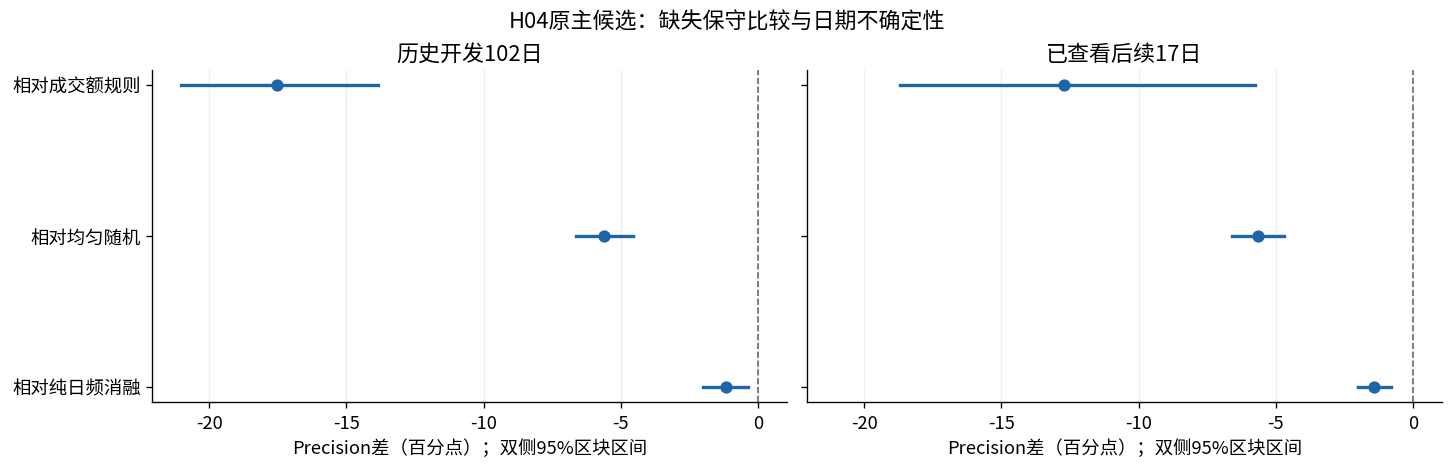

In [5]:
comparisons = []
for stage, part in daily.groupby("stage", sort=True):
    by_method = {
        method: frame.sort_values("trade_date").set_index("trade_date")
        for method, frame in part.groupby("method")
    }
    candidates = [name for name in by_method if not name.startswith("baseline_")]
    for candidate in candidates:
        current = by_method[candidate]
        jobs = [
            ("amount", by_method[comparator]["precision_upper"]),
            ("random", current["random_upper"]),
        ]
        if "_all__" in candidate:
            ablation = candidate.replace("_all__", "_daily__")
            if ablation in by_method:
                jobs.append(("daily_ablation", by_method[ablation]["precision_upper"]))
        for contrast, reference in jobs:
            assert current.index.equals(reference.index)
            differences = (current["precision_lower"] - reference).to_numpy()
            for block_length in [1, 3, 5]:
                generator = np.random.default_rng(parameters["seed"])
                starts = generator.integers(
                    0,
                    len(differences),
                    size=(
                        parameters["bootstrap_repetitions"],
                        (len(differences) + block_length - 1) // block_length,
                    ),
                )
                indices = (
                    (starts[:, :, None] + np.arange(block_length)) % len(differences)
                ).reshape(parameters["bootstrap_repetitions"], -1)[
                    :, : len(differences)
                ]
                means = differences[indices].mean(axis=1)
                comparisons.append(
                    {
                        "stage": stage,
                        "candidate": candidate,
                        "comparator": contrast,
                        "days": len(differences),
                        "block_days": block_length,
                        "mean_difference": float(differences.mean()),
                        "one_sided_95_lower": float(np.quantile(means, 0.05)),
                        "two_sided_95_lower": float(np.quantile(means, 0.025)),
                        "two_sided_95_upper": float(np.quantile(means, 0.975)),
                    }
                )
intervals = pd.DataFrame(comparisons)
intervals.to_csv(evidence / "paired-intervals.csv", index=False)
main = intervals.loc[
    intervals["candidate"].eq(primary) & intervals["block_days"].eq(5)
].copy()
main["exploratory_positive_direction"] = (main["mean_difference"] > 0) & (
    main["one_sided_95_lower"] > 0
)
display(
    main[
        [
            "stage",
            "comparator",
            "days",
            "mean_difference",
            "one_sided_95_lower",
            "two_sided_95_lower",
            "two_sided_95_upper",
            "exploratory_positive_direction",
        ]
    ].style.format(
        {
            name: "{:+.2%}"
            for name in [
                "mean_difference",
                "one_sided_95_lower",
                "two_sided_95_lower",
                "two_sided_95_upper",
            ]
        }
    )
)
fig, axes = plt.subplots(
    1, 2, figsize=(12, 3.8), layout="constrained", sharex=True, sharey=True
)
contrast_labels = {
    "amount": "相对成交额规则",
    "random": "相对均匀随机",
    "daily_ablation": "相对纯日频消融",
}
for axis, stage, caption in zip(
    axes, ["development", "followup"], ["历史开发102日", "已查看后续17日"], strict=True
):
    data = (
        main.loc[main["stage"].eq(stage)]
        .set_index("comparator")
        .loc[list(contrast_labels)]
    )
    for position, row in enumerate(data.itertuples()):
        axis.plot(
            [row.two_sided_95_lower, row.two_sided_95_upper],
            [position, position],
            color="#1d65a6",
            linewidth=2,
        )
        axis.scatter(row.mean_difference, position, color="#1d65a6", s=40)
    axis.axvline(0, color="#626a73", linestyle="--", linewidth=1)
    axis.set_yticks(range(3), list(contrast_labels.values()))
    axis.set_title(caption)
    axis.set_xlabel("Precision差（百分点）；双侧95%区块区间")
    axis.xaxis.set_major_formatter(
        ticker.FuncFormatter(lambda value, position: f"{value * 100:.0f}")
    )
    axis.grid(axis="x", alpha=0.2)
axes[0].invert_yaxis()
fig.suptitle("H04原主候选：缺失保守比较与日期不确定性")
fig.savefig(evidence / "primary-paired-intervals.png")
plt.show()
monthly = (
    daily.loc[daily["method"].isin([primary, comparator])]
    .assign(month=lambda x: x["trade_date"].str[:7])
    .groupby(["stage", "month", "method"])
    .agg(
        days=("trade_date", "size"),
        mean_hits=("hits", "mean"),
        precision_lower=("precision_lower", "mean"),
        precision_upper=("precision_upper", "mean"),
    )
    .reset_index()
)
monthly.to_csv(evidence / "monthly.csv", index=False)
display(
    monthly.pivot(
        index=["stage", "month", "days"], columns="method", values="precision_lower"
    )
    .rename(columns=labels_map)
    .style.format("{:.2%}")
)

## 6. 独立核验：冻结名单、计数和 sklearn

使用原始预测分重新排序，核对名单；独立布尔选择向量核对每一个模型日。将未知标签按最有利/最不利两种方式赋值，再由 sklearn 直接计算 Precision、Recall、F1，与边界公式比较。小样本另外穷举全部未知事件，验证边界可以达到且不会遗漏可能结果。


In [6]:
cache = {}
checked = 0
for row in original.itertuples(index=False):
    frame = frames[row.trade_date]
    symbols = frame.index.to_numpy()
    labels = frame["y_rank_return"].to_numpy()
    if row.method.startswith("baseline_"):
        scores = frame[row.method].to_numpy()
    else:
        candidate, window = row.method.split("__")
        if row.stage == "development":
            directory = f"development-{window}"
        else:
            directory = {
                primary: "new-primary",
                "hist_all__last60": "new-reference",
                "ridge_daily__expanding": "new-ablation",
            }[row.method]
        relative = f"{directory}/predictions-{row.trade_date}.parquet"
        if relative not in cache:
            cache[relative] = pd.read_parquet(inputs / relative).set_index("symbol")
        prediction = cache[relative]
        pd.testing.assert_series_equal(
            prediction["y_rank_return"].sort_index(),
            frame["y_rank_return"].sort_index(),
        )
        assert len(prediction) == len(frame)
        scores = prediction.reindex(frame.index)[candidate].to_numpy()
    ordering = np.lexsort((symbols, np.where(np.isnan(scores), np.inf, -scores)))
    assert symbols[ordering[:50]].tolist() == list(row.selected_symbols)
    chosen = np.isin(symbols, row.selected_symbols)
    unknown = pd.isna(labels)
    known_positive = (~unknown) & (labels > parameters["rank_cutoff_strict"])
    worst = known_positive | (unknown & ~chosen)
    best = known_positive | (unknown & chosen)
    actual = daily.loc[
        daily["stage"].eq(row.stage)
        & daily["trade_date"].eq(row.trade_date)
        & daily["method"].eq(row.method)
    ].iloc[0]
    assert int(np.count_nonzero(chosen & known_positive)) == actual["hits"]
    assert int(np.count_nonzero(known_positive)) == actual["known_positive"]
    for truth, bound in [(worst, "lower"), (best, "upper")]:
        observed = [
            precision_score(truth, chosen),
            recall_score(truth, chosen),
            f1_score(truth, chosen),
        ]
        expected_values = [
            actual[f"{metric}_{bound}"] for metric in ["precision", "recall", "f1"]
        ]
        np.testing.assert_allclose(observed, expected_values, rtol=0, atol=1e-14)
        np.testing.assert_allclose(
            observed[0] / truth.mean(), actual[f"lift_{bound}"], rtol=0, atol=1e-14
        )
    checked += 1
fixture_cases = 0
assignments_checked = 0
for states in itertools.product([-1, 0, 1], repeat=5):
    values = np.array(states)
    if not np.any(values == 1):
        continue
    chosen = np.array([True, True, False, False, False])
    missing = values == -1
    positive = values == 1
    fixture = pd.DataFrame(
        [
            {
                "pool_size": 5,
                "selected_count": 2,
                "known_positive": int(positive.sum()),
                "unknown_count": int(missing.sum()),
                "selected_unknown": int((missing & chosen).sum()),
                "hits": int((positive & chosen).sum()),
            }
        ]
    )
    expected_bounds = _add_metrics(fixture).iloc[0]
    outcomes = []
    for bits in itertools.product([False, True], repeat=int(missing.sum())):
        truth = positive.copy()
        truth[missing] = bits
        measured = [
            precision_score(truth, chosen),
            recall_score(truth, chosen),
            f1_score(truth, chosen),
        ]
        measured.append(measured[0] / truth.mean())
        outcomes.append(measured)
        assignments_checked += 1
    for position, metric in enumerate(["precision", "recall", "f1", "lift"]):
        np.testing.assert_allclose(
            [
                np.min(np.array(outcomes)[:, position]),
                np.max(np.array(outcomes)[:, position]),
            ],
            [expected_bounds[f"{metric}_lower"], expected_bounds[f"{metric}_upper"]],
            rtol=0,
            atol=1e-14,
        )
    fixture_cases += 1
bootstrap_checks = 0
for stage in ["development", "followup"]:
    current = daily.loc[
        daily["stage"].eq(stage) & daily["method"].eq(primary)
    ].sort_values("trade_date")
    reference = daily.loc[
        daily["stage"].eq(stage) & daily["method"].eq(comparator)
    ].sort_values("trade_date")
    values = (
        current["precision_lower"].to_numpy() - reference["precision_upper"].to_numpy()
    )
    generator = np.random.default_rng(parameters["seed"])
    starts = generator.integers(0, len(values), size=(10000, (len(values) + 4) // 5))
    means = []
    for start_row in starts:
        positions = [
            (int(start) + offset) % len(values)
            for start in start_row
            for offset in range(5)
        ][: len(values)]
        means.append(float(np.mean([values[position] for position in positions])))
    actual = intervals.loc[
        intervals["stage"].eq(stage)
        & intervals["candidate"].eq(primary)
        & intervals["comparator"].eq("amount")
        & intervals["block_days"].eq(5)
    ].iloc[0]
    np.testing.assert_allclose(
        np.quantile(means, [0.05, 0.025, 0.975]),
        actual[
            ["one_sided_95_lower", "two_sided_95_lower", "two_sided_95_upper"]
        ].to_numpy(dtype=float),
        rtol=0,
        atol=1e-14,
    )
    bootstrap_checks += 1
for item in manifest:
    for base in [prior, inputs]:
        with (base / item["path"]).open("rb") as handle:
            assert hashlib.file_digest(handle, "sha256").hexdigest() == item["sha256"]
audit = {
    "method_dates_recomputed": checked,
    "original_prediction_files_rechecked": len(cache),
    "synthetic_missingness_cases": fixture_cases,
    "unknown_truth_assignments": assignments_checked,
    "primary_bootstrap_intervals_recomputed": bootstrap_checks,
    "source_and_copied_input_files_unchanged": len(manifest),
    "all_passed": True,
}
(evidence / "verification.json").write_text(json.dumps(audit, indent=2) + "\n")
print(json.dumps(audit, indent=2))

{
  "method_dates_recomputed": 1190,
  "original_prediction_files_rechecked": 255,
  "synthetic_missingness_cases": 211,
  "unknown_truth_assignments": 781,
  "primary_bootstrap_intervals_recomputed": 2,
  "source_and_copied_input_files_unchanged": 264,
  "all_passed": true
}


## 7. 结果导出与解释边界

`summary.csv` 保存所有模型的日期等权指标，`daily-metrics.parquet` 保留每个分子分母；`paired-intervals.csv` 保留所有对照和区块长度，`monthly.csv` 保留分月结果。主候选角色不变。

本次只能检验既有参考窗口下的相对强收益事件。真实可交易机会需原始收益、成本、风险及执行定义；“值得观察”需固定有/无新增 L2 的决策比较。本次结果不构成净 alpha 或真实接收对齐证明。

In [7]:
result = {
    "parameters": parameters,
    "universe": json.loads(
        universe.groupby("stage")
        .agg(
            days=("trade_date", "size"),
            mean_pool=("pool_size", "mean"),
            mean_known_opportunities=("known_positive", "mean"),
            unknown_labels=("unknown_count", "sum"),
            random_precision_lower=("random_lower", "mean"),
            random_precision_upper=("random_upper", "mean"),
        )
        .reset_index()
        .to_json(orient="records")
    ),
    "metrics": json.loads(summary.to_json(orient="records", double_precision=15)),
    "primary_comparisons": json.loads(
        main.to_json(orient="records", double_precision=15)
    ),
    "audit": audit,
    "interpretation": {
        "all_results_posthoc": True,
        "new_holdout_available": False,
        "old_failures_preserved": True,
        "real_time_alignment_verified": False,
        "net_alpha_verified": False,
    },
}
(evidence / "result.json").write_text(
    json.dumps(result, ensure_ascii=False, indent=2) + "\n"
)
print("结果与证据:", evidence)
print("主候选:", primary)
print("所有结果均为探索性补充；未验证净 alpha 或真实接收。")

结果与证据: /home/wsw/app/research-evidence/subscription-opportunity-metrics-2026-09-22-zg1az9fa
主候选: ridge_all__expanding
所有结果均为探索性补充；未验证净 alpha 或真实接收。


## 8. 结果后的定向数据质量补查

此节记录结果后的诊断，不属于本轮指标选择，也未删除任何日期。独立脚本及输出：

- [实际执行的质量补查脚本](/home/wsw/app/research-evidence/subscription-opportunity-metrics-2026-09-22-zg1az9fa/quality_diagnostic.py)
- [补查结果与限制](/home/wsw/app/research-evidence/subscription-opportunity-metrics-2026-09-22-zg1az9fa/quality-diagnostic.json)
- [181日标签并列分布](/home/wsw/app/research-evidence/subscription-opportunity-metrics-2026-09-22-zg1az9fa/label-tie-profile.csv)

6月8日事前池的5,193个有效标签中，5,103个完全相同；该日前10%已知机会仅90只。其他日期最大并列组最多4只。

从正式文件只读复制6月8/9日沪深分钟及复权因子六个对象后，检查发现两日 `[14:31,14:36)` 的 **25,723条连续交易分钟行、5,196个证券**，去掉日期偏移后全部字段相同。按既有公式重算，当日标签全集中5,106个参考收益恰为零，排名与H04冻结标签完全一致。事前池与当日标签全集不同，因此5,103与5,106并不矛盾。

异常已存在于 processed 分钟输入；原始文件、下载或处理环节的根因尚未查明。六对象快照、哈希及实际脚本保存在同一证据目录。该质量发现可能影响训练标签及特征；不能把数学计算复现成功当作市场数据真实性已经通过。
